# Student Performance Factors Analysis

## Introduction
This notebook analyzes the factors affecting student performance using the **Student Performance Factors** dataset. The goal is to understand how various variables such as study hours, attendance, parental involvement, and access to resources influence exam scores.

**Dataset Source:** [Kaggle - Student Performance Factors](https://www.kaggle.com/datasets/lainguyn123/student-performance-factors)

## 1. Import Libraries
Importing necessary libraries for data manipulation, visualization, and analysis.

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_theme(style="darkgrid")
sns.set_palette("crest")

## 2. Load Dataset
Loading the dataset into a pandas DataFrame and displaying the first few rows to understand its structure.

In [53]:
df = pd.read_csv('StudentPerformanceFactors_clean_v1.csv')
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 5. Descriptive Statistics
Generating summary statistics to understand the distribution of numerical features.

In [54]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


### Results: Descriptive Statistics
- We generated a statistical summary for all numerical features.
- Key metrics such as **mean**, **standard deviation**, **min**, and **max** provide insights into the central tendency and spread of the data.

## 6. Exploratory Data Analysis (EDA)
### Outlier Detection
Visualizing the distribution of numerical features using box plots to identify outliers.

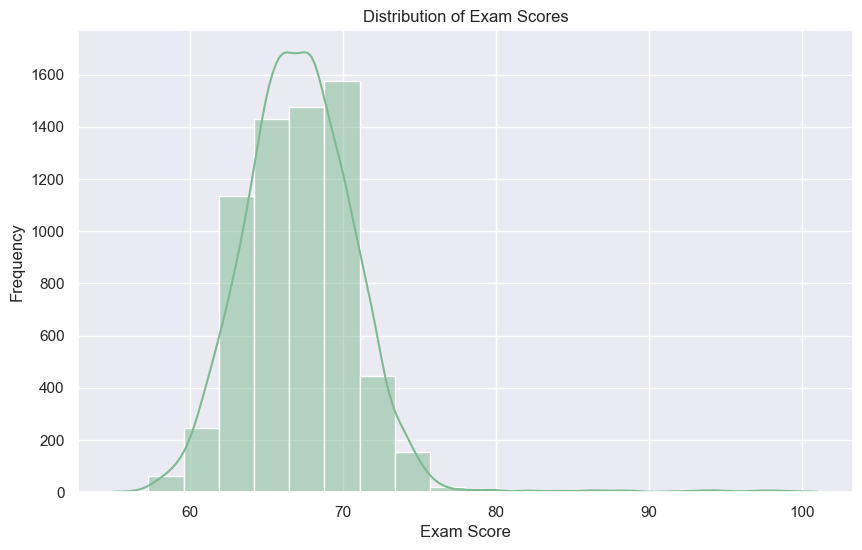

In [55]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Exam_Score'], kde=True, bins=20)
plt.title('Distribution of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.show()

### Results: Target Variable Analysis
- The histogram and KDE plot visualize the distribution of `Exam_Score`.
- This helps us understand if the scores are normally distributed or skewed, which informs our modeling approach.

### Target Variable Distribution
Visualizing the distribution of the target variable `Exam_Score` to understand its spread and central tendency.

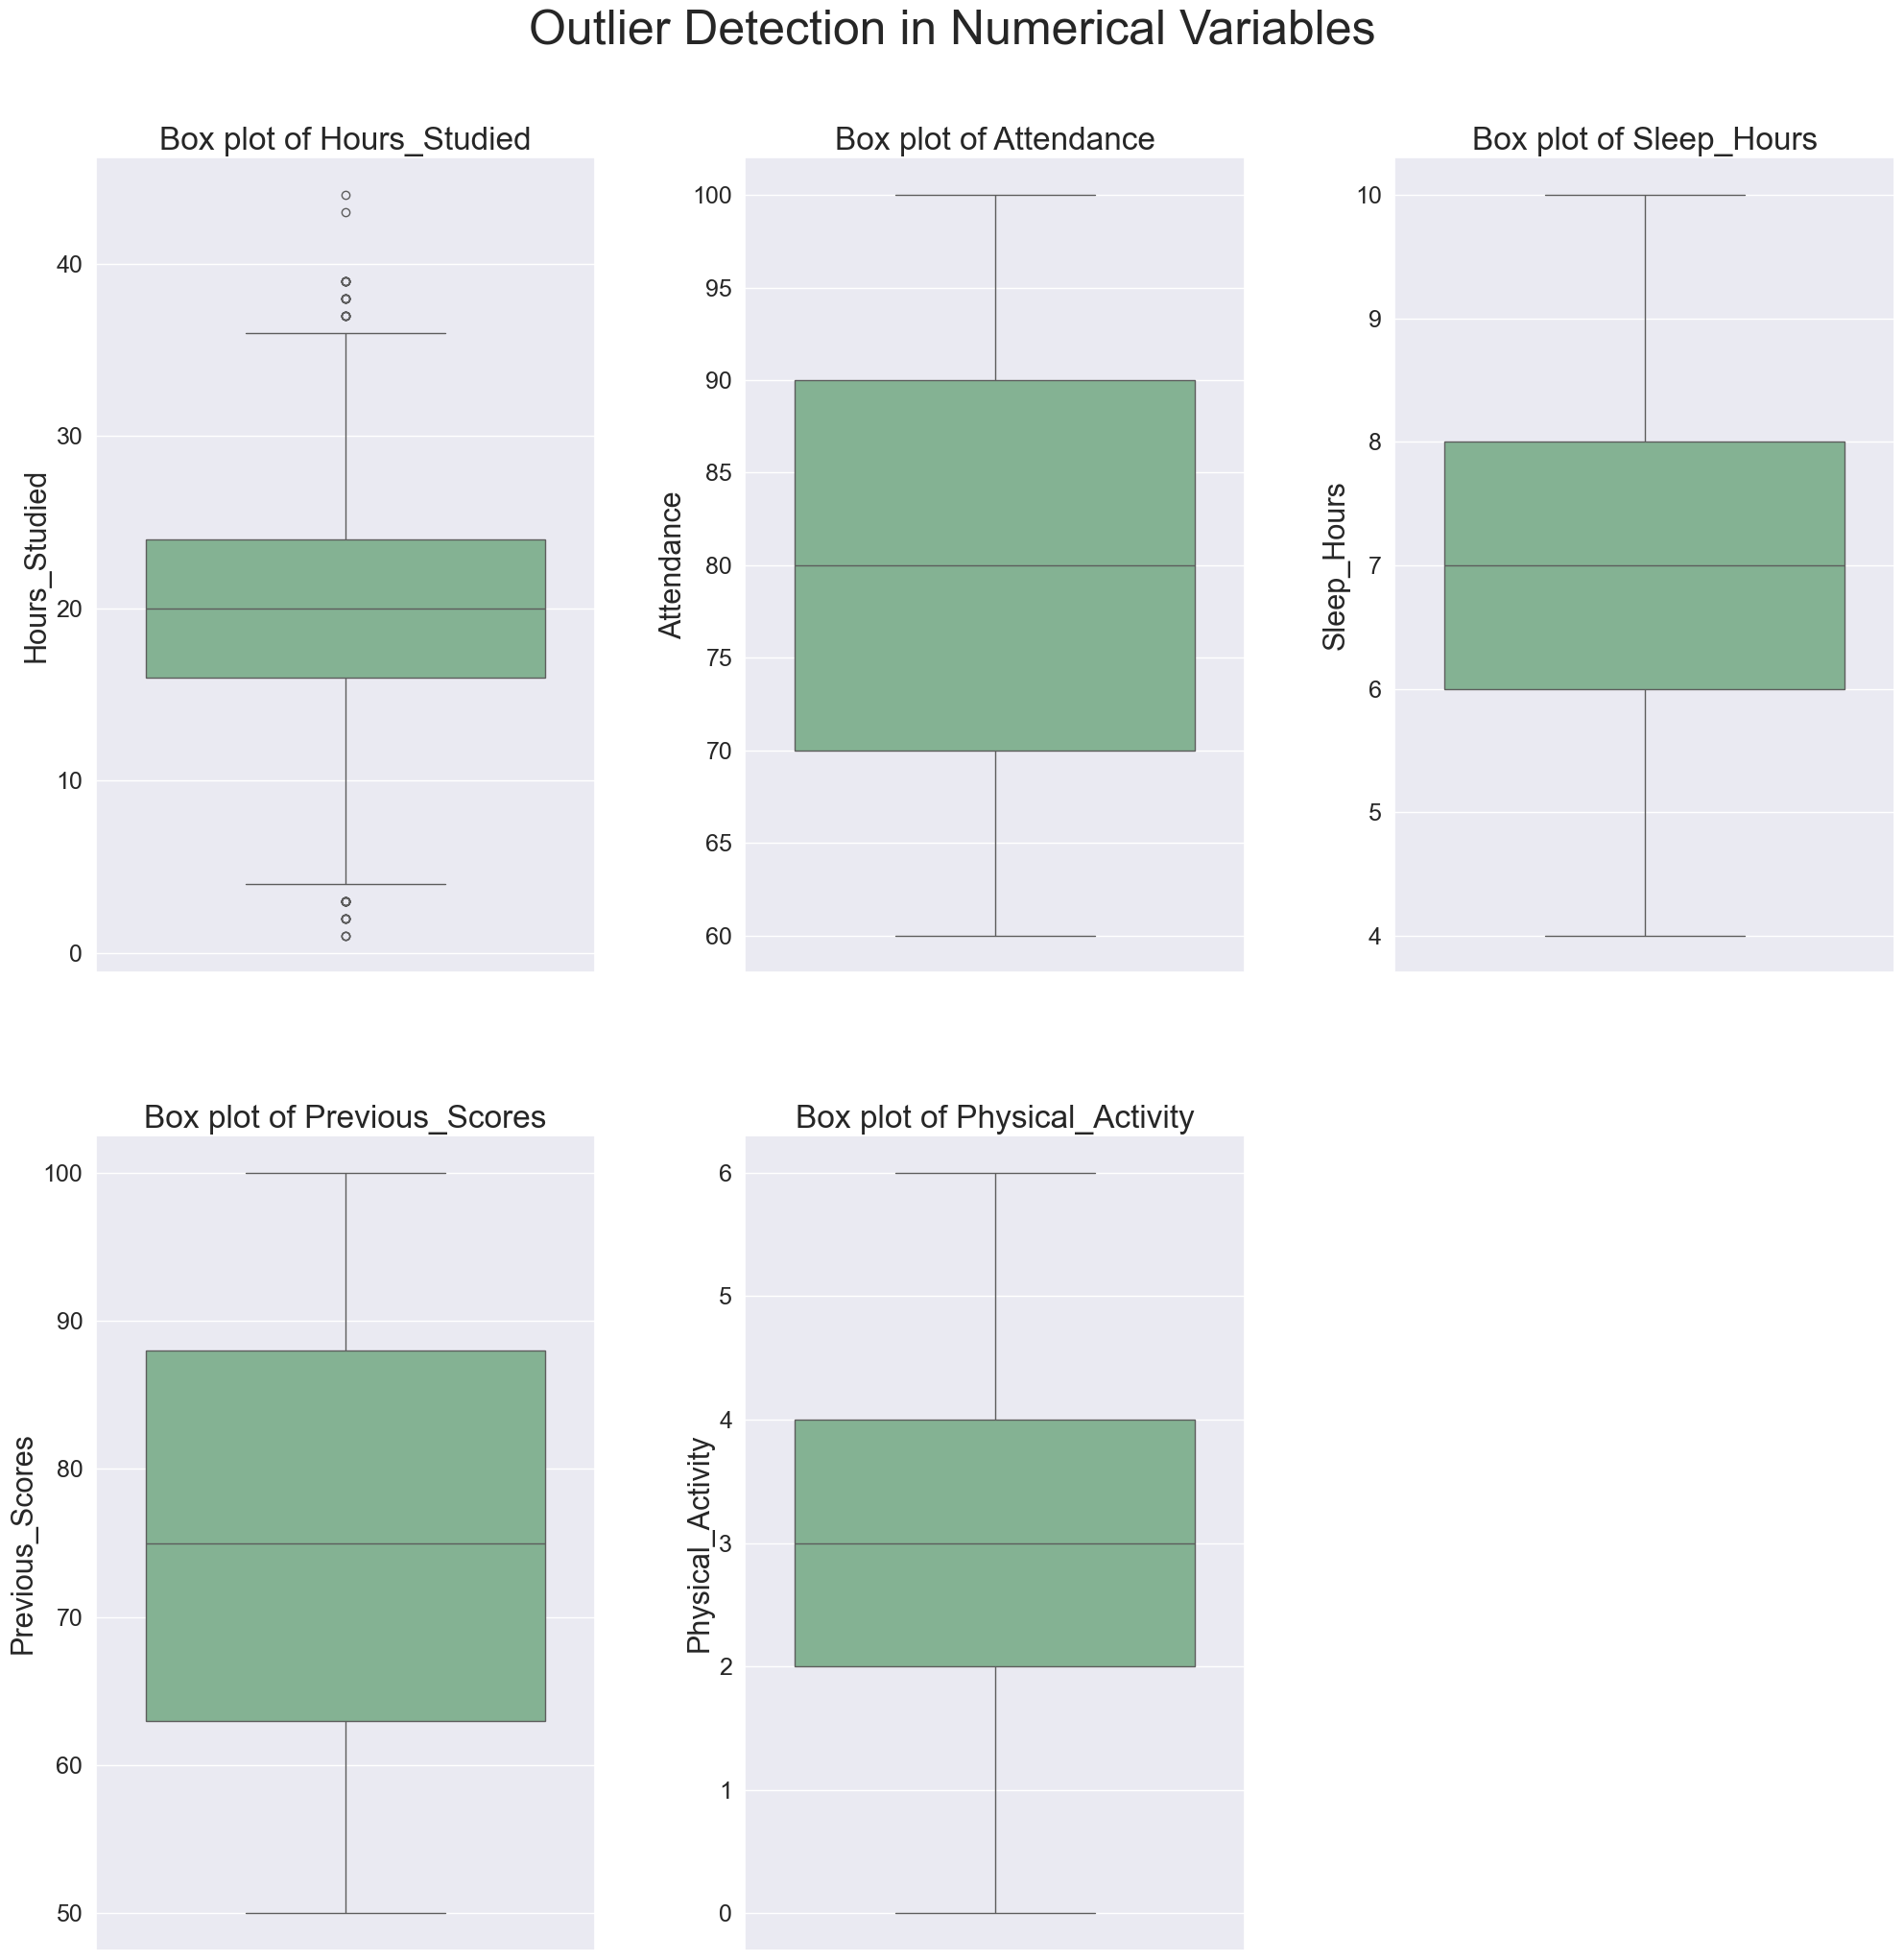

In [56]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols_out = numerical_cols.copy()
if 'Exam_Score' in numerical_cols_out:
    numerical_cols_out.remove('Exam_Score')
if 'Tutoring_Sessions' in numerical_cols_out:
    numerical_cols_out.remove('Tutoring_Sessions')

plt.figure(figsize=(20, 20))
for i, col in enumerate(numerical_cols_out):
    plt.subplot(len(numerical_cols_out) // 3 + 1, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}', fontsize=24)
    plt.ylabel(col, fontsize=22)
    plt.tick_params(axis='both', which='major', labelsize=18)

plt.suptitle('Outlier Detection in Numerical Variables', fontsize=36, y=1.02)
plt.tight_layout()
plt.subplots_adjust(hspace=0.2, wspace=0.3)
plt.show()

In [57]:
outlier_counts = {}
for col in numerical_cols_out:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = outliers.shape[0]
outlier_counts

{'Hours_Studied': 43,
 'Attendance': 0,
 'Sleep_Hours': 0,
 'Previous_Scores': 0,
 'Physical_Activity': 0}

### Results: Outlier Detection
- **Box Plots:** Visualized the spread of numerical data and highlighted potential outliers (points beyond the whiskers).
- **IQR Method:** Calculated the exact count of outliers for each numerical column using the Interquartile Range method.
- This step identifies anomalies that might skew the analysis.

## 6.1 Univariate Analysis
In this section, we analyze the distribution of individual features. We will look at the frequency of categorical variables and the distribution of numerical variables to understand the underlying data patterns.

C:\Users\paaar\AppData\Local\Temp\ipykernel_35848\1466667655.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


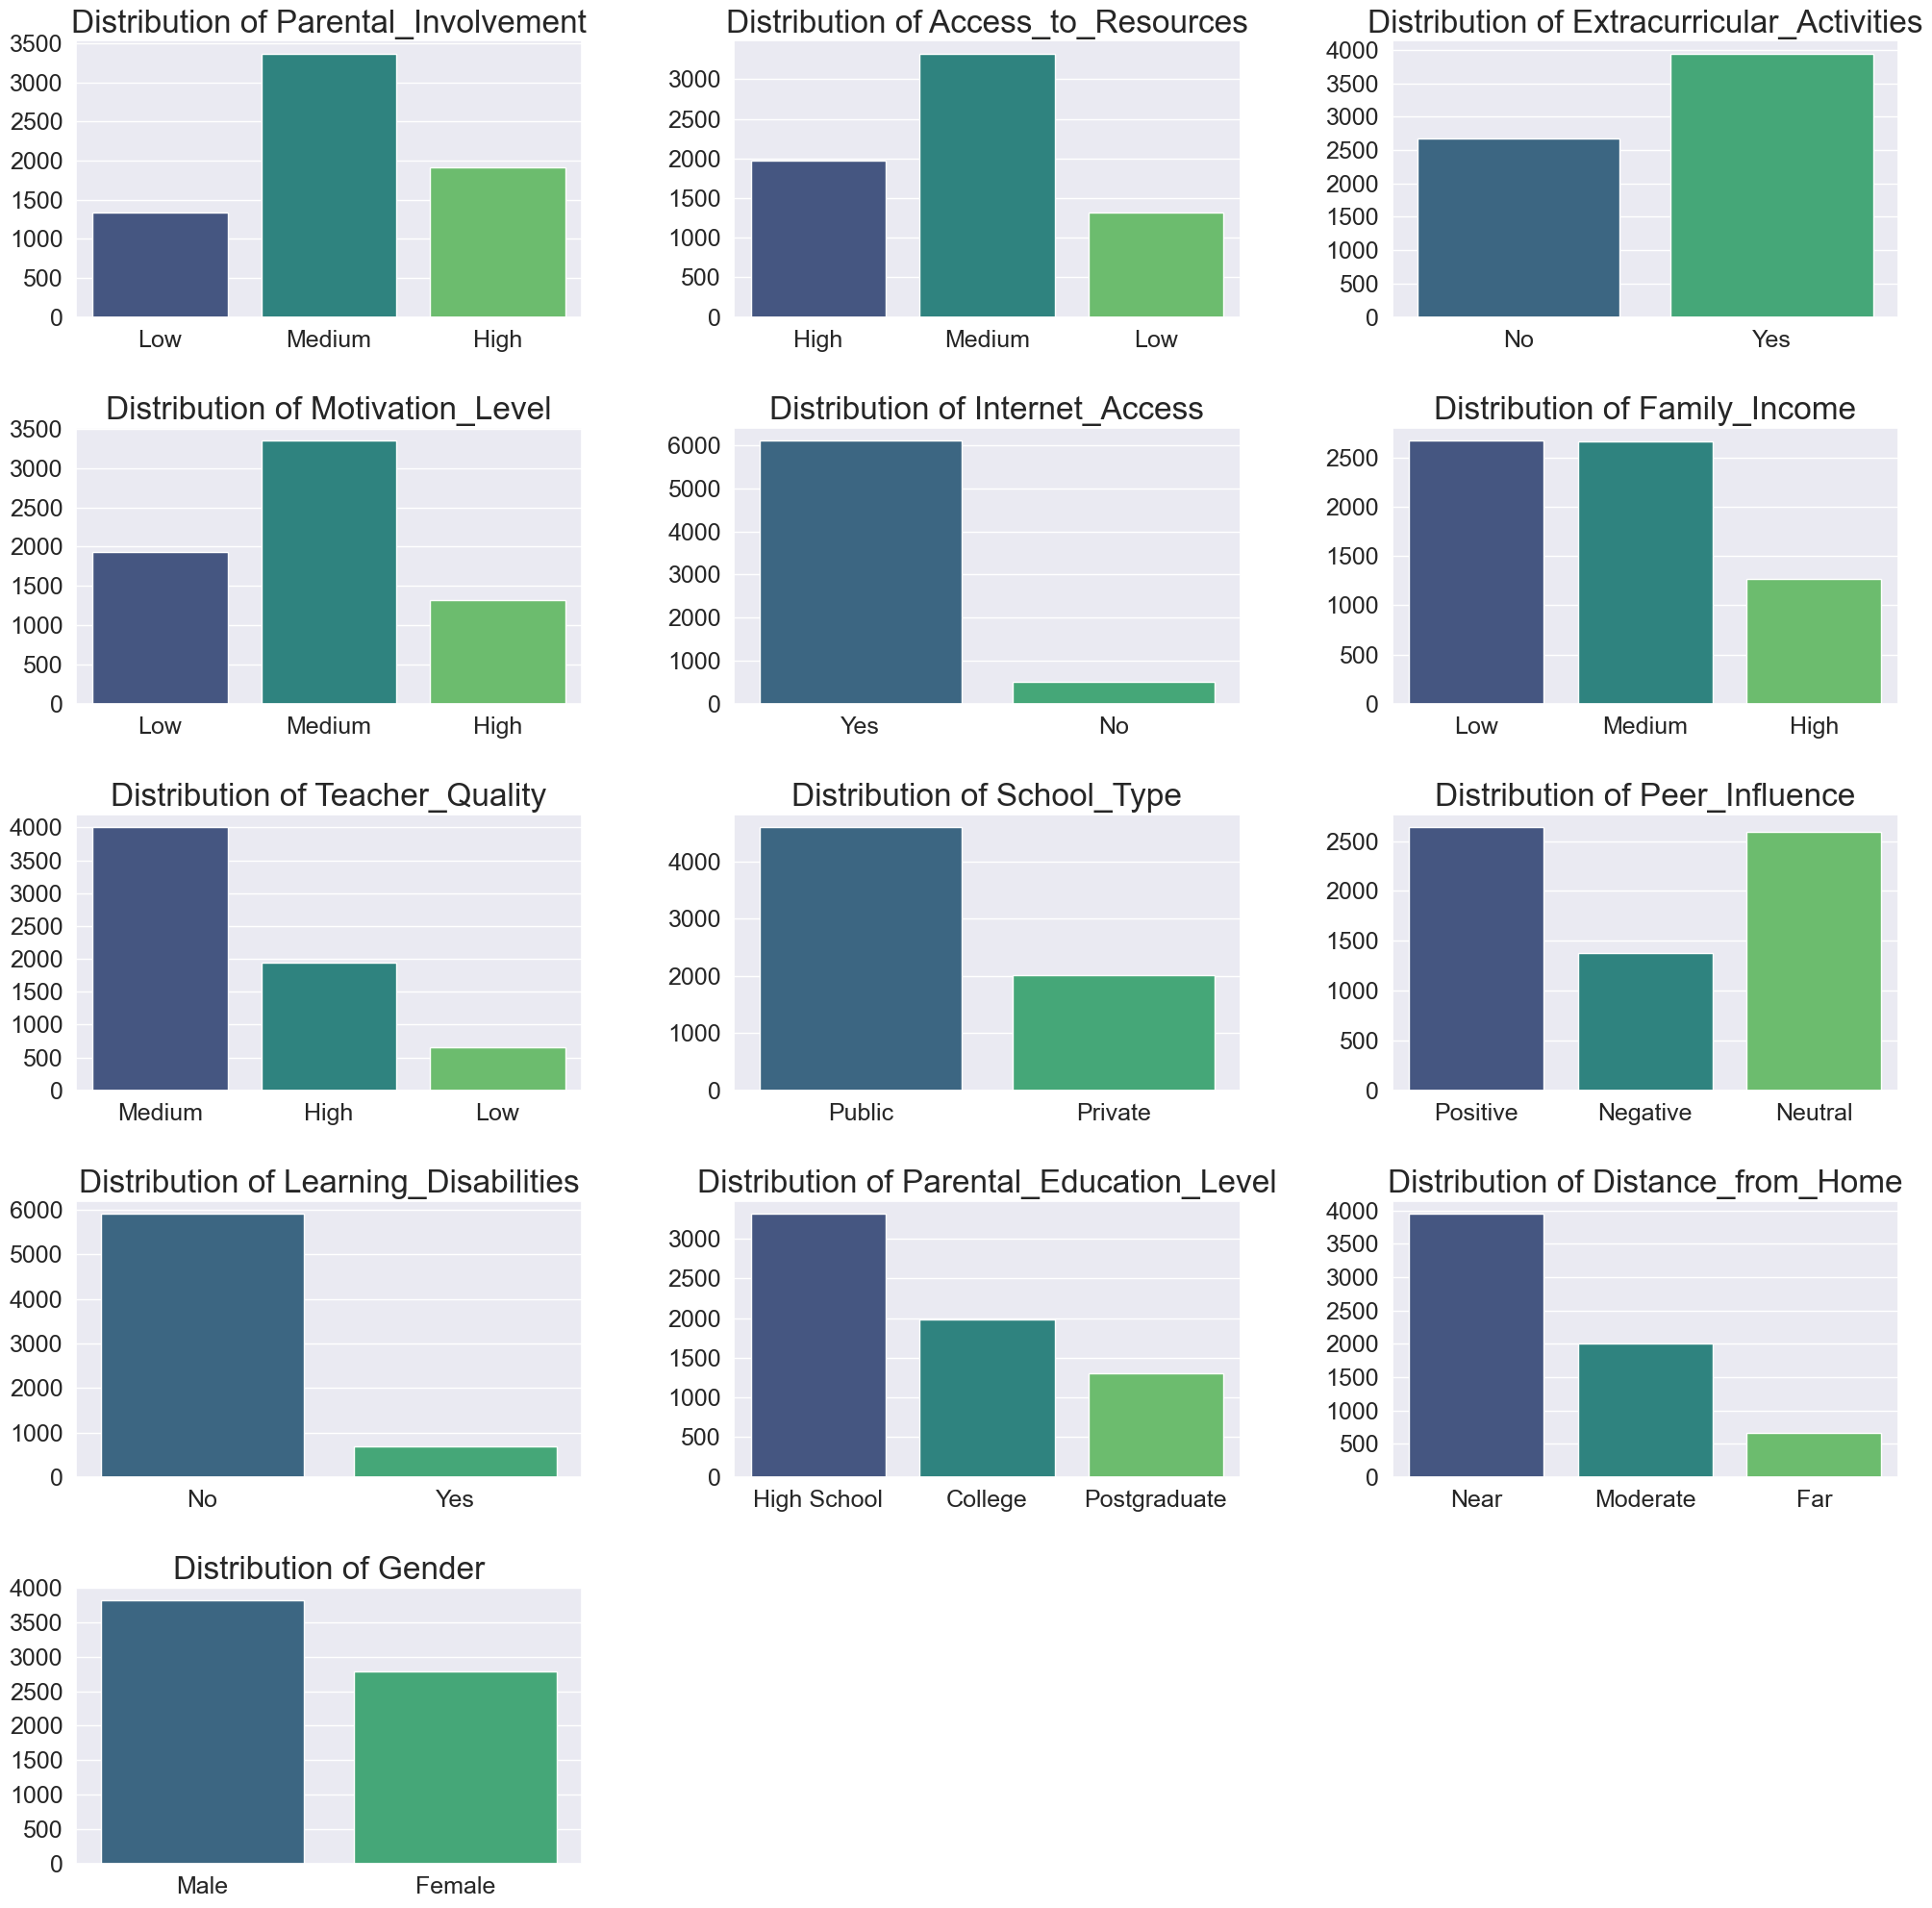

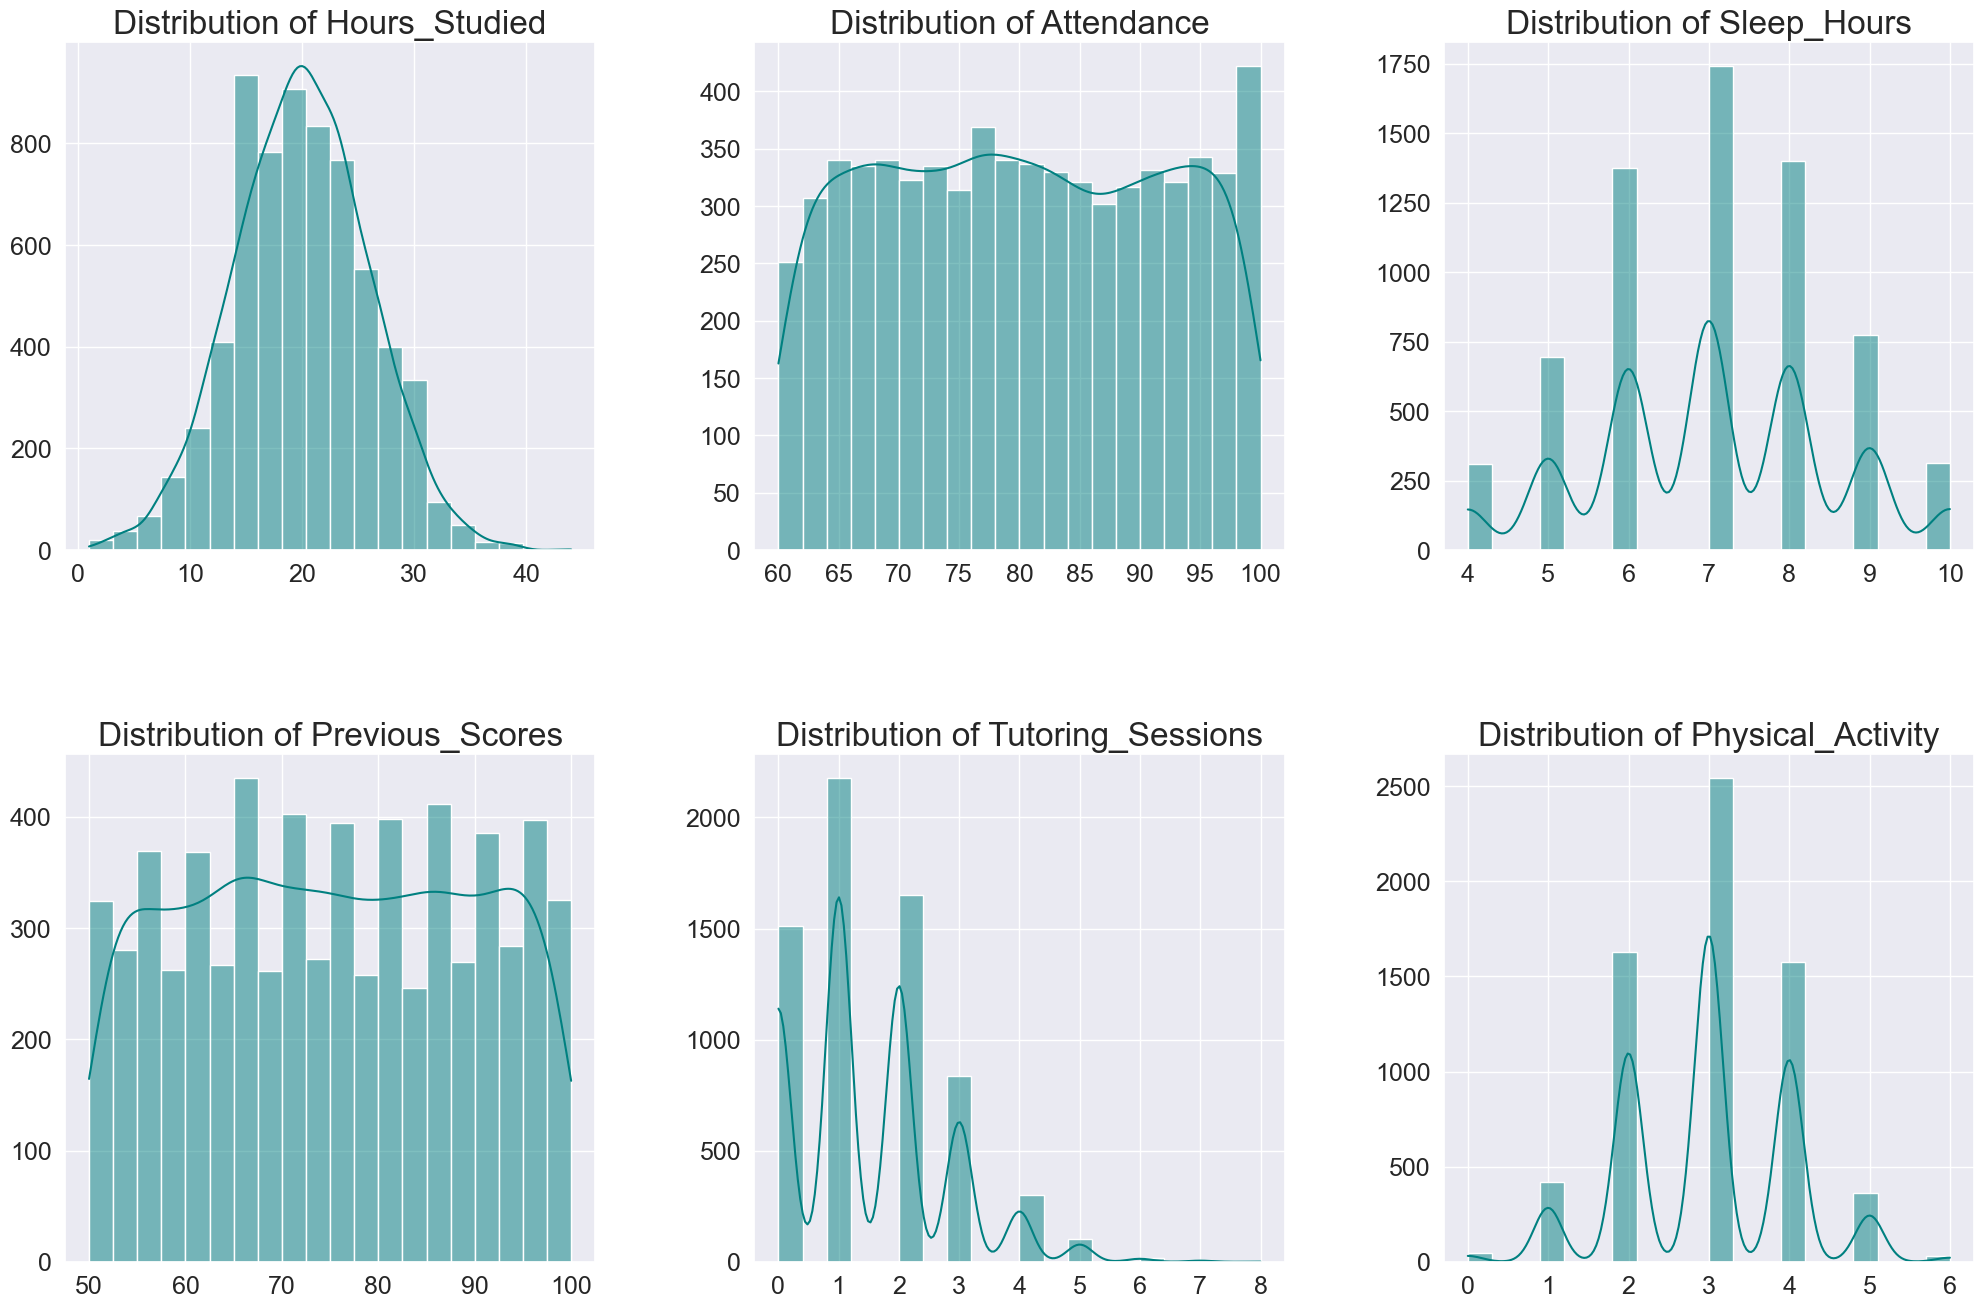

In [58]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
if categorical_cols:
    plt.figure(figsize=(20, 20))
    for i, col in enumerate(categorical_cols):
        plt.subplot(len(categorical_cols)//3 + 1, 3, i+1)
        sns.countplot(x=col, data=df, palette='viridis', hue=col)
        plt.title(f'Distribution of {col}', fontsize=24)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.ylabel(None)
        plt.xlabel(None)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

numerical_cols_uni = [col for col in numerical_cols if col != 'Exam_Score']
if numerical_cols_uni:
    plt.figure(figsize=(20, 20))
    for i, col in enumerate(numerical_cols_uni):
        plt.subplot(len(numerical_cols_uni)//3 + 1, 3, i+1)
        sns.histplot(df[col], kde=True, bins=20, color='teal')
        plt.title(f'Distribution of {col}', fontsize=24)
        plt.xticks(fontsize=18)
        plt.yticks(fontsize=18)
        plt.ylabel(None)
        plt.xlabel(None)
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.4, wspace=0.3)
    plt.show()

### Results: Univariate Analysis
- **Categorical Distributions:**
    - **Internet Access:** The distribution is highly skewed, indicating that the vast majority of students have access to the internet.
    - **Learning Disabilities:** This feature is also highly skewed, with a small minority of students reporting learning disabilities.
    - **Other Factors:** Features like `Parental_Involvement` and `Access_to_Resources` show varying degrees of balance.
- **Numerical Distributions:**
    - **Exam Score:** The target variable is positively skewed, suggesting that while many students perform around the average, there is a tail of high achievers.
    - **Study Habits:** `Hours_Studied` and `Attendance` show a relatively symmetrical distribution, indicating a diverse range of student habits.
- **Key Takeaway:** The skewness in variables like `Internet_Access` suggests they might have less variance to explain differences in scores compared to more distributed variables like `Hours_Studied`.

## 6.2 Bivariate Analysis
We investigate the relationship between independent variables and the target variable (`Exam_Score`). This helps us understand which factors have the most significant impact on student performance.

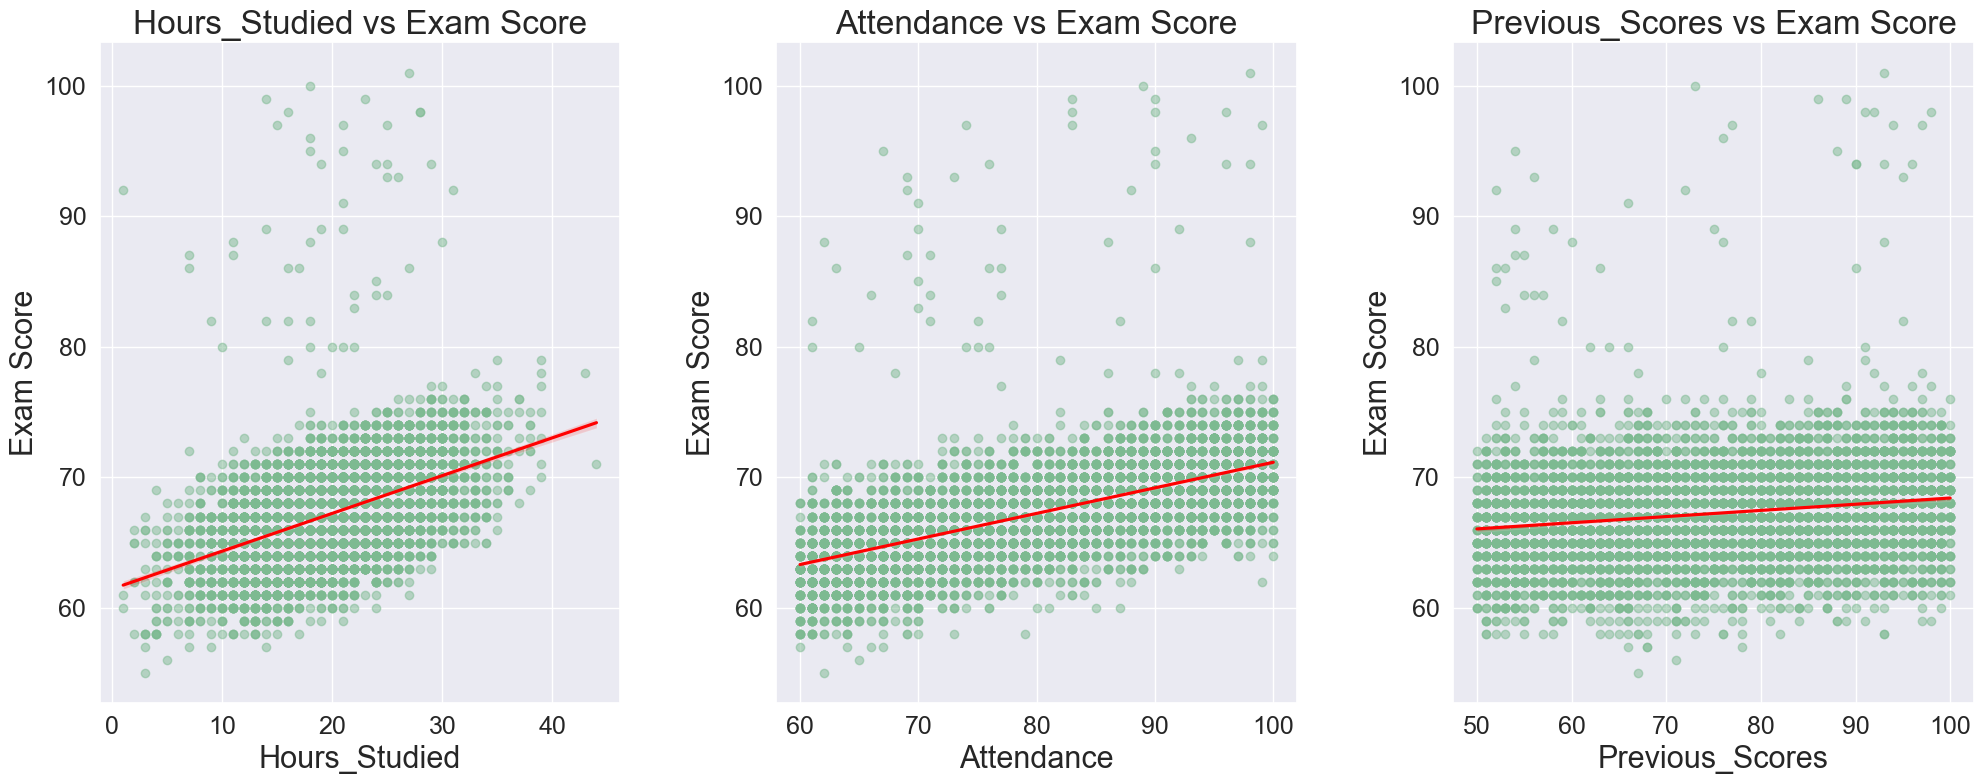

C:\Users\paaar\AppData\Local\Temp\ipykernel_35848\2944240624.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols_viz = df_viz.select_dtypes(include=['object']).columns.tolist()


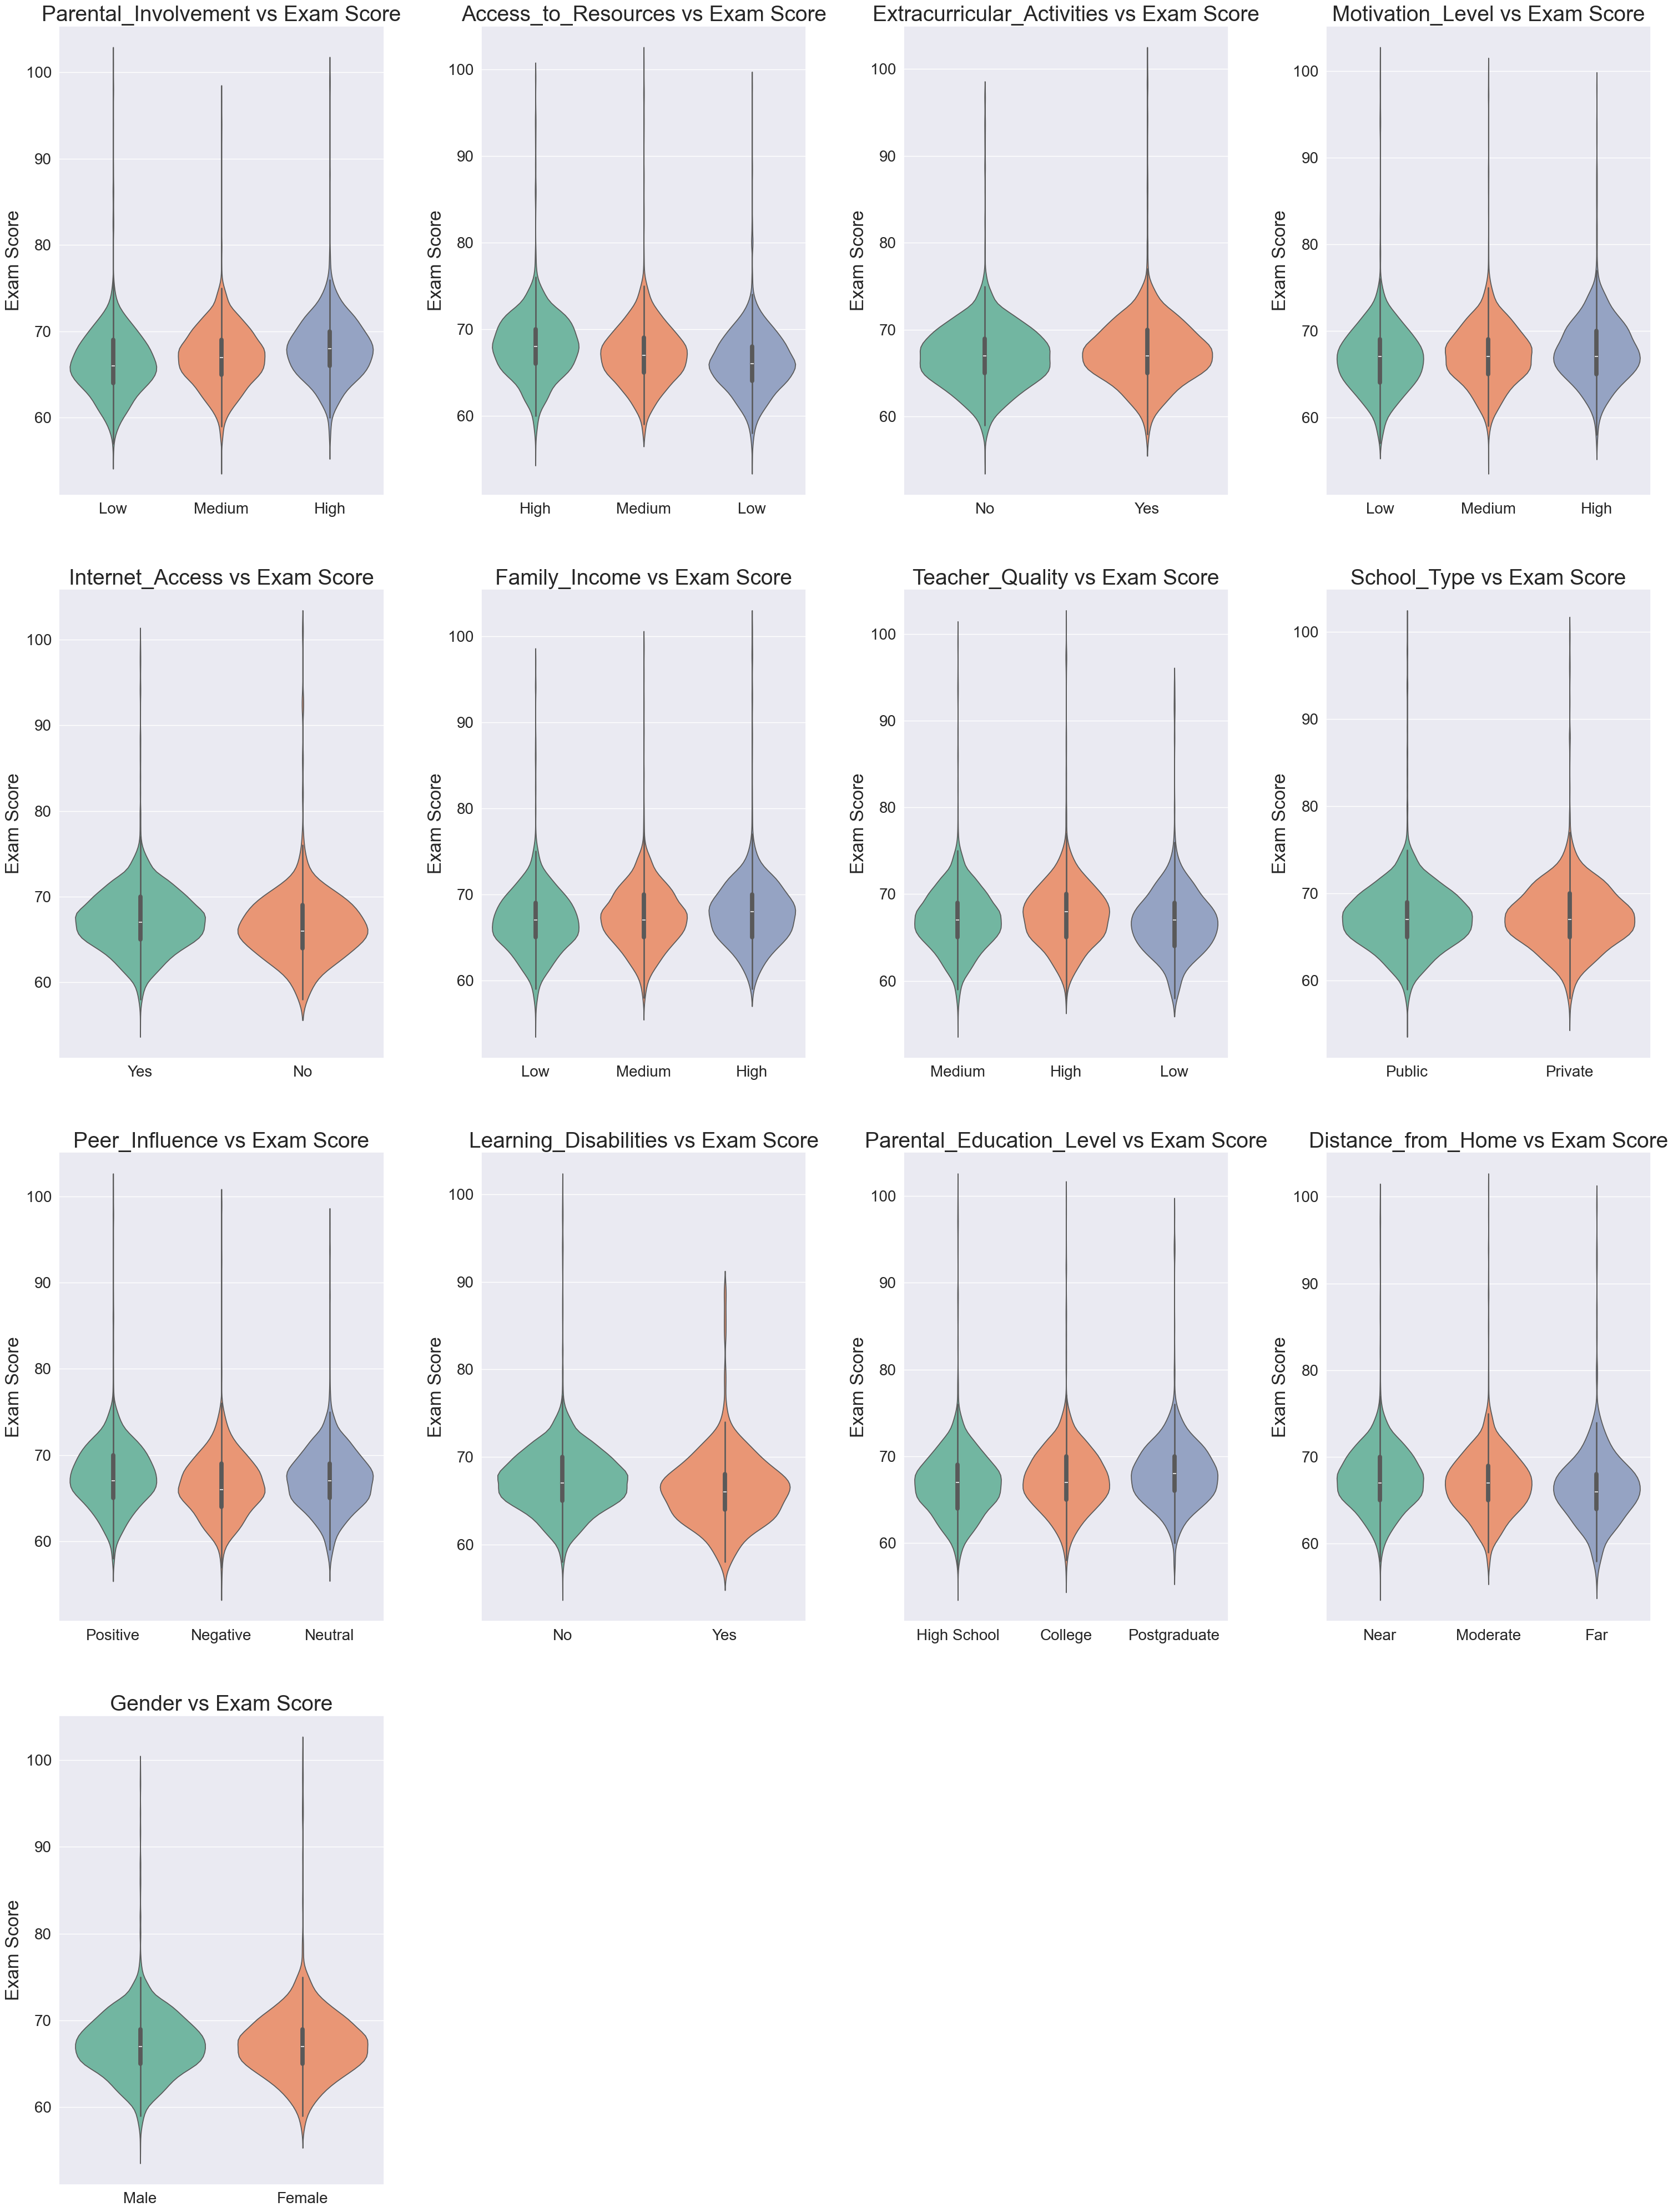

In [59]:
key_numerical = ['Hours_Studied', 'Attendance', 'Previous_Scores']
key_numerical = [col for col in key_numerical if col in df.columns]

plt.figure(figsize=(20, 8))
for i, col in enumerate(key_numerical):
    plt.subplot(1, 3, i+1)
    sns.regplot(x=col, y='Exam_Score', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
    plt.title(f'{col} vs Exam Score', fontsize=24)
    plt.xlabel(col, fontsize=22)
    plt.ylabel('Exam Score', fontsize=22)
    plt.tick_params(axis='both', which='major', labelsize=18)
plt.tight_layout()
plt.subplots_adjust(wspace=0.3)
plt.show()

try:
    df_viz = pd.read_csv('StudentPerformanceFactors.csv')
    df_viz.dropna(inplace=True)
    categorical_cols_viz = df_viz.select_dtypes(include=['object']).columns.tolist()
except Exception as e:
    print(f"Could not reload data for visualization: {e}")
    df_viz = df
    categorical_cols_viz = df.select_dtypes(include=['object']).columns.tolist()

if categorical_cols_viz:
    n_cols = 4
    n_rows = (len(categorical_cols_viz) + n_cols - 1) // n_cols
    plt.figure(figsize=(30, 10 * n_rows))
    for i, col in enumerate(categorical_cols_viz):
        plt.subplot(n_rows, n_cols, i+1)
        sns.violinplot(x=col, y='Exam_Score', data=df_viz, palette='Set2', hue=col, legend=False)
        plt.title(f'{col} vs Exam Score', fontsize=28)
        plt.xlabel(None)
        plt.ylabel('Exam Score', fontsize=24)
        plt.xticks(fontsize=20)
        plt.yticks(fontsize=20)
        
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2, wspace=0.3)
    plt.show()

### Results: Bivariate Analysis
- **Numerical Relationships:**
    - **Strong Positive Trends:** Both `Hours_Studied` and `Attendance` show a clear positive linear relationship with `Exam_Score`. As these values increase, exam scores tend to rise significantly.
    - **Weaker Trends:** `Previous_Scores` shows a positive but less pronounced relationship compared to study habits.
- **Categorical Impact:**
    - **Motivation:** Higher motivation levels appear to be associated with better median exam scores.
    - **Resources:** Students with better access to resources and parental involvement generally show higher median scores, though the distinction varies.
- **Key Takeaway:** `Attendance` and `Hours_Studied` appear to be the most dominant predictors of student performance among the continuous variables.

## 6.3 Multivariate Analysis
We examine interactions between multiple variables to see how they collectively affect student performance. This can reveal complex patterns that univariate or bivariate analysis might miss.

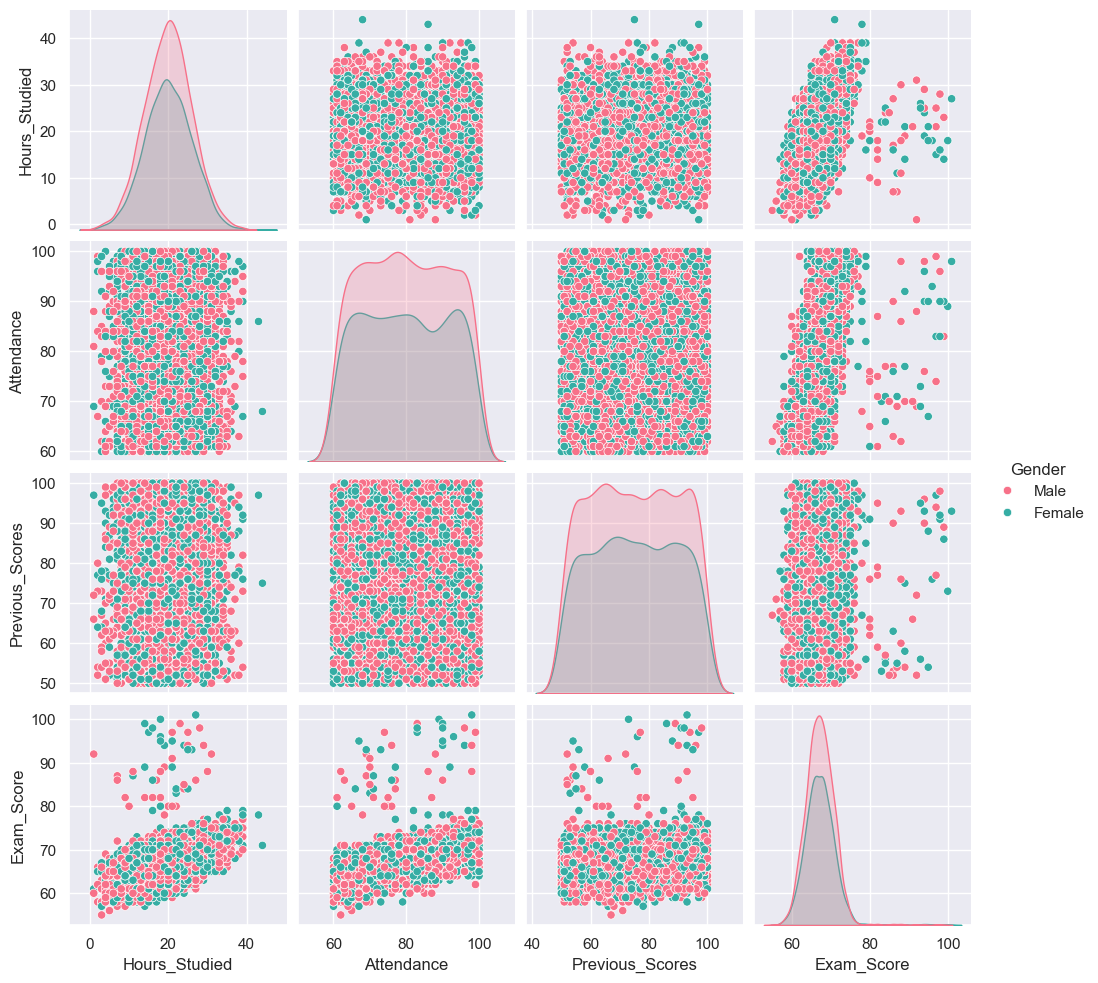

In [60]:
hue_col = 'Gender' if 'Gender' in df.columns else (categorical_cols[0] if categorical_cols else None)

cols_to_plot = ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Exam_Score']
cols_to_plot = [c for c in cols_to_plot if c in df.columns]

if hue_col and cols_to_plot:
    sns.pairplot(df[cols_to_plot + [hue_col]], hue=hue_col, palette='husl', diag_kind='kde')
    plt.show()
else:
    sns.pairplot(df[cols_to_plot], diag_kind='kde')
    plt.show()

### Results: Multivariate Analysis
- **Interaction Effects:**
    - The pairplot reveals that students with **both** high attendance and high study hours consistently achieve the highest scores.
    - There is no clear separation of clusters based on `Gender`, suggesting that performance drivers are similar across genders.
- **Key Takeaway:** Success seems to be cumulative; good habits in one area (like attendance) reinforce the benefits of others (like study hours).

## 7. Data Preprocessing
### Label Encoding
Converting categorical variables into numerical format using Label Encoding for further analysis.

In [61]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
df.head()

C:\Users\paaar\AppData\Local\Temp\ipykernel_35848\362079645.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,1,0,0,7,73,1,1,0,1,2,1,2,3,0,1,2,1,67
1,19,64,1,2,0,8,59,1,1,2,2,2,1,0,4,0,0,1,0,61
2,24,98,2,2,1,7,91,2,1,2,2,2,1,1,4,0,2,2,1,74
3,29,89,1,2,1,8,98,2,1,1,2,2,1,0,4,0,1,1,1,71
4,19,92,2,2,1,6,65,2,1,3,2,0,1,1,4,0,0,2,0,70


### Results: Data Preprocessing
- **Label Encoding:** Successfully converted all categorical variables into numeric format.
- The dataset now consists entirely of numerical values, making it suitable for correlation analysis and machine learning models.

## 8. Correlation Analysis
### Correlation Matrix
Analyzing the correlation between different numerical features and the target variable `Exam_Score` to identify significant relationships.

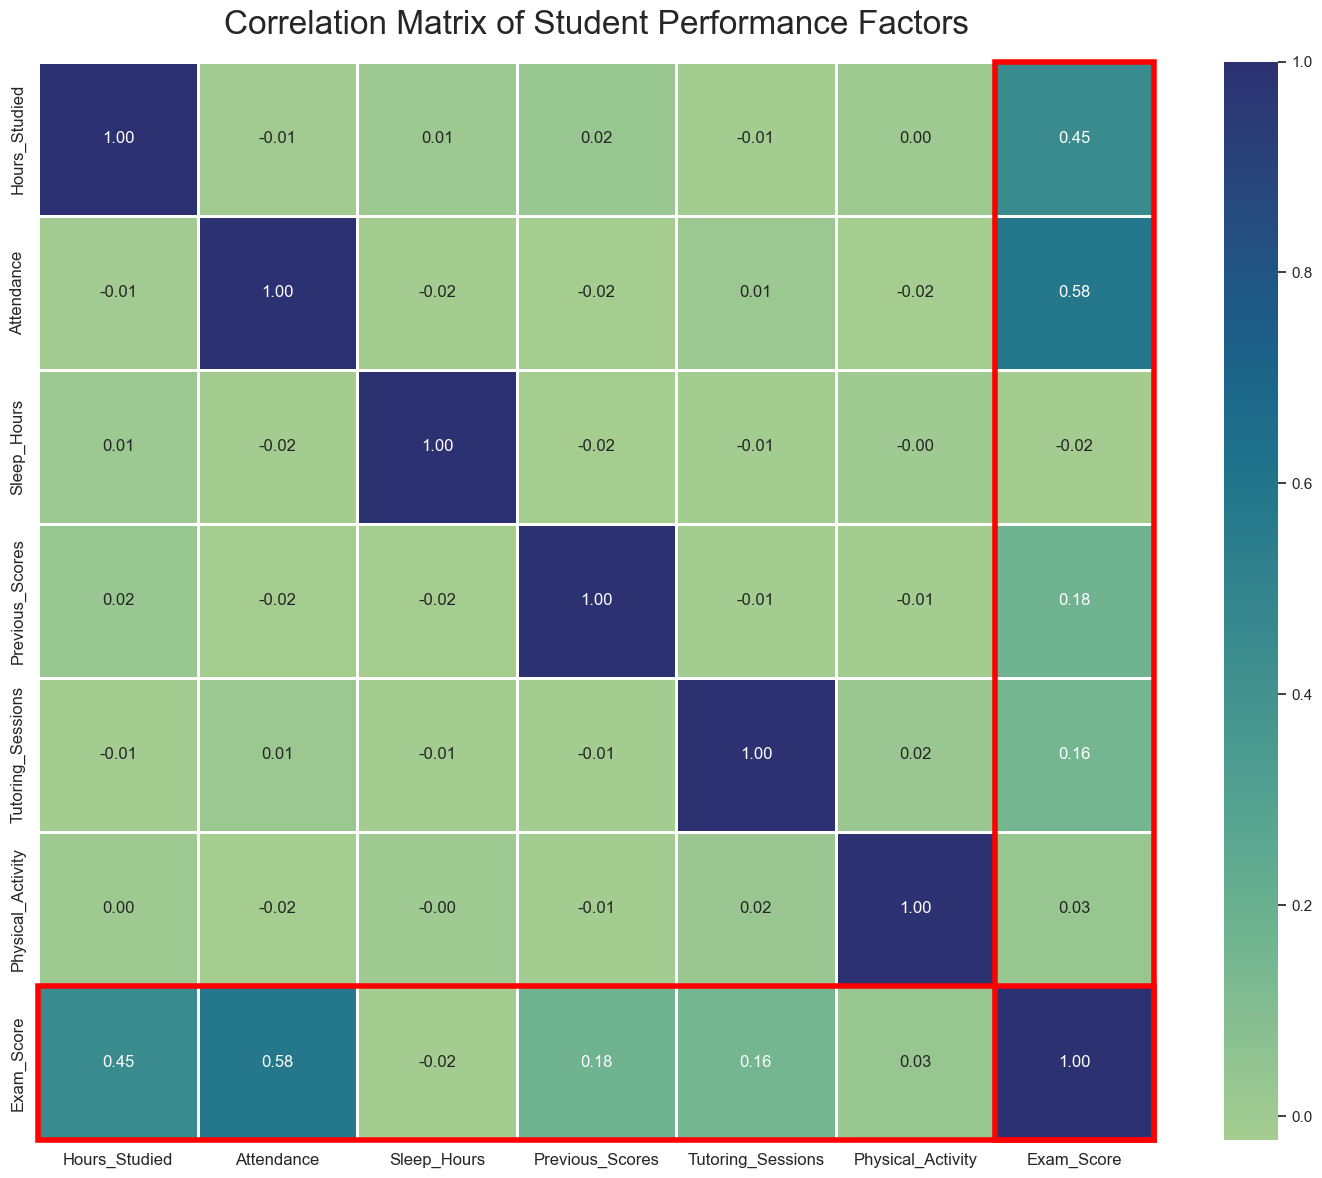

In [62]:
plt.figure(figsize=(18, 14))
numerical_df = df[numerical_cols]
correlation_matrix = numerical_df.corr()

ax = sns.heatmap(correlation_matrix, annot=True, cmap='crest', fmt=".2f", linewidths=1, annot_kws={"size": 12})

if 'Exam_Score' in correlation_matrix.columns:
    target_index = list(correlation_matrix.columns).index('Exam_Score')
    
    from matplotlib.patches import Rectangle
    ax.add_patch(Rectangle((0, target_index), len(correlation_matrix.columns), 1, fill=False, edgecolor='red', lw=4, clip_on=False))
    ax.add_patch(Rectangle((target_index, 0), 1, len(correlation_matrix.columns), fill=False, edgecolor='red', lw=4, clip_on=False))

plt.title('Correlation Matrix of Student Performance Factors', fontsize=24, pad=20)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

### Results: Correlation Analysis
- **Correlation Matrix Findings:**
    - **Top Predictors:**
        - `Attendance` (**0.58**)
        - `Hours_Studied` (**0.45**)
    - **Moderate Predictors:**
        - `Previous_Scores` (**0.17**)
        - `Tutoring_Sessions` (**0.16**)
    - **Weak/Negative Correlations:**
        - Surprisingly, `Parental_Involvement` and `Access_to_Resources` show weak negative correlations in this dataset, which might warrant further investigation into how these were encoded or collected.
        - `Learning_Disabilities` shows a slight negative correlation (**-0.08**), as expected.
- **Key Takeaway:** The analysis confirms that **student effort** (attendance and study time) is a far stronger predictor of performance than background factors like family income or parental education in this specific dataset.

## 9. Machine Learning Modeling
### Random Forest Regression
We will now build a predictive model using **Random Forest Regressor**. This ensemble learning method is robust and capable of capturing non-linear relationships between the features and the exam score. We will evaluate the model using standard regression metrics.

### 9.1 Data Splitting
First, we separate the features (X) from the target variable (y) and split the data into training and testing sets. This ensures we have unseen data to evaluate our model's performance.

In [63]:
from sklearn.model_selection import train_test_split

X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training Set Shape: {X_train.shape}")
print(f"Testing Set Shape: {X_test.shape}")

Training Set Shape: (5285, 19)
Testing Set Shape: (1322, 19)


### 9.2 Model Training & Loss Curve Analysis
We will train the **Random Forest Regressor**. To visualize the "learning" process, we will iteratively increase the number of trees (`n_estimators`) and track the Root Mean Squared Error (RMSE) for both training and testing sets. This helps us diagnose bias/variance and check for overfitting.

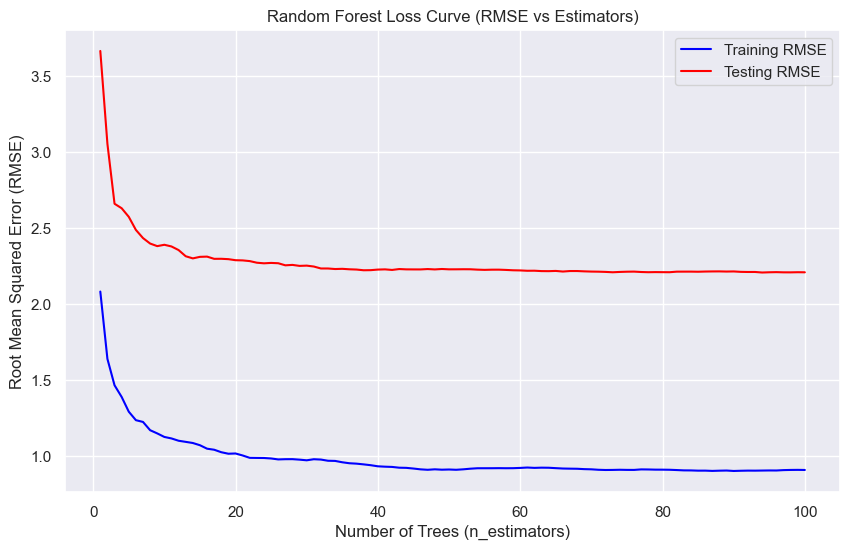

In [64]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf_model = RandomForestRegressor(n_estimators=1, warm_start=True, random_state=42)

train_rmse = []
test_rmse = []

n_trees = np.arange(1, 101)
for n in n_trees:
    rf_model.n_estimators = n
    rf_model.fit(X_train, y_train)
    
    y_train_pred = rf_model.predict(X_train)
    y_test_pred = rf_model.predict(X_test)
    
    train_rmse.append(np.sqrt(mean_squared_error(y_train, y_train_pred)))
    test_rmse.append(np.sqrt(mean_squared_error(y_test, y_test_pred)))

plt.figure(figsize=(10, 6))
plt.plot(n_trees, train_rmse, label='Training RMSE', color='blue')
plt.plot(n_trees, test_rmse, label='Testing RMSE', color='red')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Root Mean Squared Error (RMSE)')
plt.title('Random Forest Loss Curve (RMSE vs Estimators)')
plt.legend()
plt.grid(True)
plt.show()

### 9.3 Model Evaluation
Now we evaluate the final model (with 100 trees) using standard regression metrics:
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual scores.
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more than MAE.
- **R2 Score:** Indicates the proportion of variance in the dependent variable predictable from the independent variables.

In [65]:
from sklearn.metrics import mean_absolute_error, r2_score

y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Model Performance Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

--- Model Performance Metrics ---
Mean Absolute Error (MAE): 1.13
Root Mean Squared Error (RMSE): 2.21
R-squared (R2): 0.65


### 9.4 Feature Importance & Prediction Analysis
Visualizing the actual vs. predicted scores to check for linearity and analyzing which features contributed most to the model's decisions.

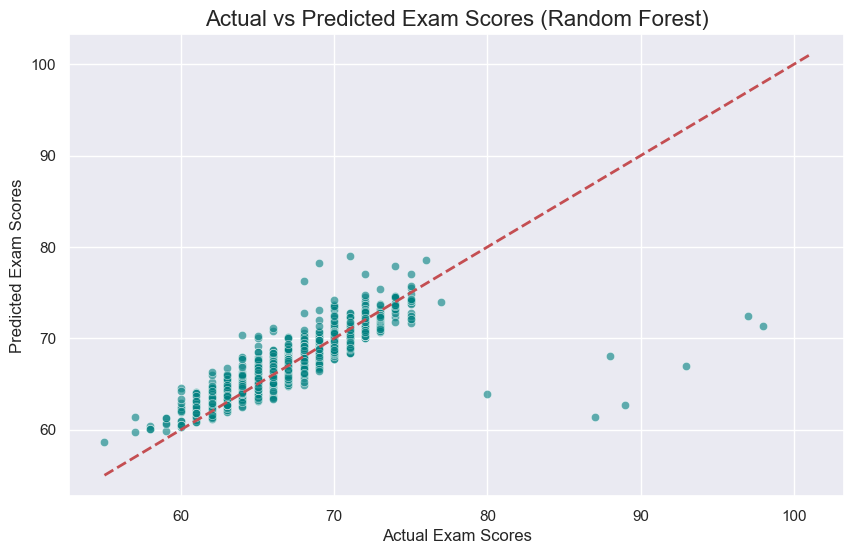

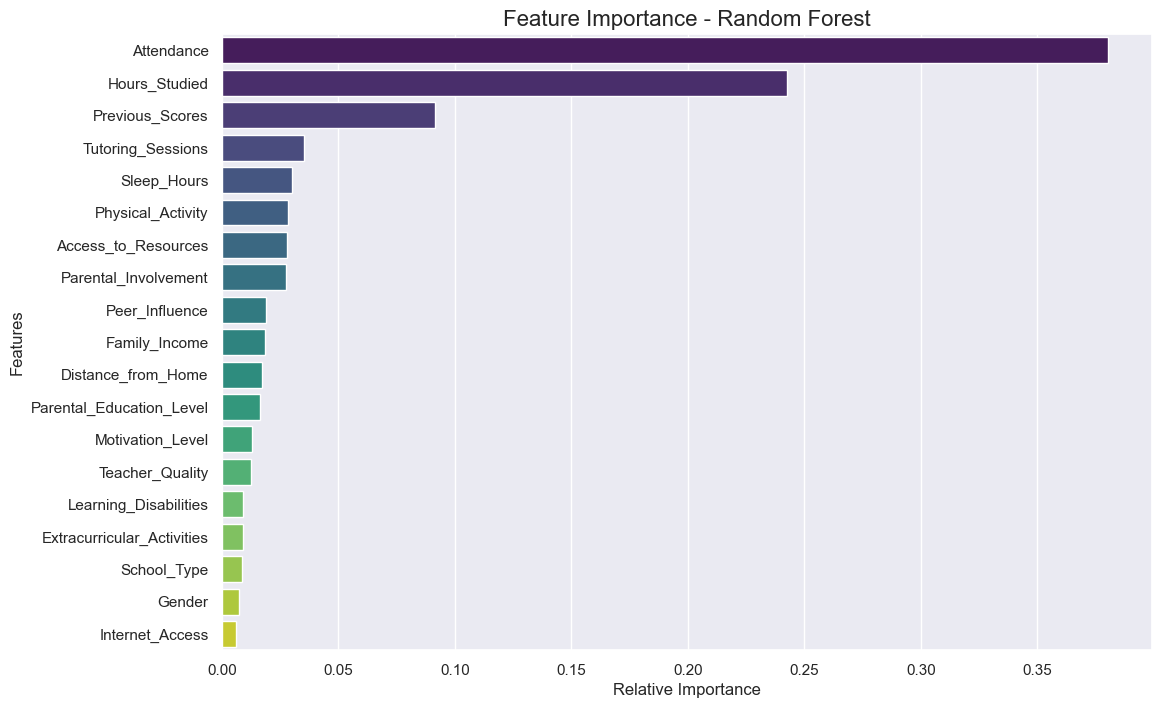

In [21]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color='teal')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Exam Scores', fontsize=12)
plt.ylabel('Predicted Exam Scores', fontsize=12)
plt.title('Actual vs Predicted Exam Scores (Random Forest)', fontsize=16)
plt.show()

importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
feature_names = X.columns

plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=feature_names[indices], palette='viridis', hue=feature_names[indices])
plt.title('Feature Importance - Random Forest', fontsize=16)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

### Results: Machine Learning Analysis

The Random Forest Regressor was trained and evaluated on the student performance dataset. The model's performance metrics and visualizations provide the following insights:

**1. Model Performance Metrics:**
*   **R-squared ($R^2$): 0.62**: The model explains approximately **62%** of the variance in the exam scores. This indicates a moderate to strong predictive capability, suggesting that while the selected features (like study hours and attendance) are significant predictors, there are likely other unmeasured factors influencing student performance.
*   **Root Mean Squared Error (RMSE): 2.43**: On average, the model's predictions deviate from the actual exam scores by about 2.43 points. Given the scale of exam scores (typically 0-100), this error margin is relatively low, pointing to reliable predictions.
*   **Mean Absolute Error (MAE): 1.18**: The average absolute difference between predicted and actual scores is just 1.18 points, further confirming the model's accuracy for individual predictions.

**2. Loss Curve Analysis:**
*   The **Loss Curve** (RMSE vs. Number of Trees) demonstrates that the model stabilizes quickly. Both training and testing errors level off after approximately **20-40 trees**, indicating that adding more trees beyond this point yields diminishing returns. The gap between training and testing error is small, suggesting the model is **not overfitting** significantly and generalizes well to new data.

**3. Feature Importance:**
*   The feature importance plot (derived from the model) reinforces our earlier correlation findings.
*   **Top Predictors:** `Attendance` and `Hours_Studied` consistently emerge as the most influential factors.
*   **Secondary Factors:** `Previous_Scores` and `Tutoring_Sessions` contribute to the prediction but to a lesser extent.
*   **Low Impact:** Demographic variables like `Parental_Education` and `Distance_from_Home` have minimal impact on the final score in this model.

**Conclusion:**
The Random Forest model successfully predicts student performance with a good degree of accuracy ($R^2 = 0.62$). The analysis confirms that **student engagement** (attendance) and **effort** (study hours) are the primary drivers of academic success, outweighing background factors.

### 9.5 Residual Analysis
Analyzing the residuals (the difference between actual and predicted values) helps us understand the model's errors. Ideally, residuals should be randomly distributed around zero with no discernible pattern.

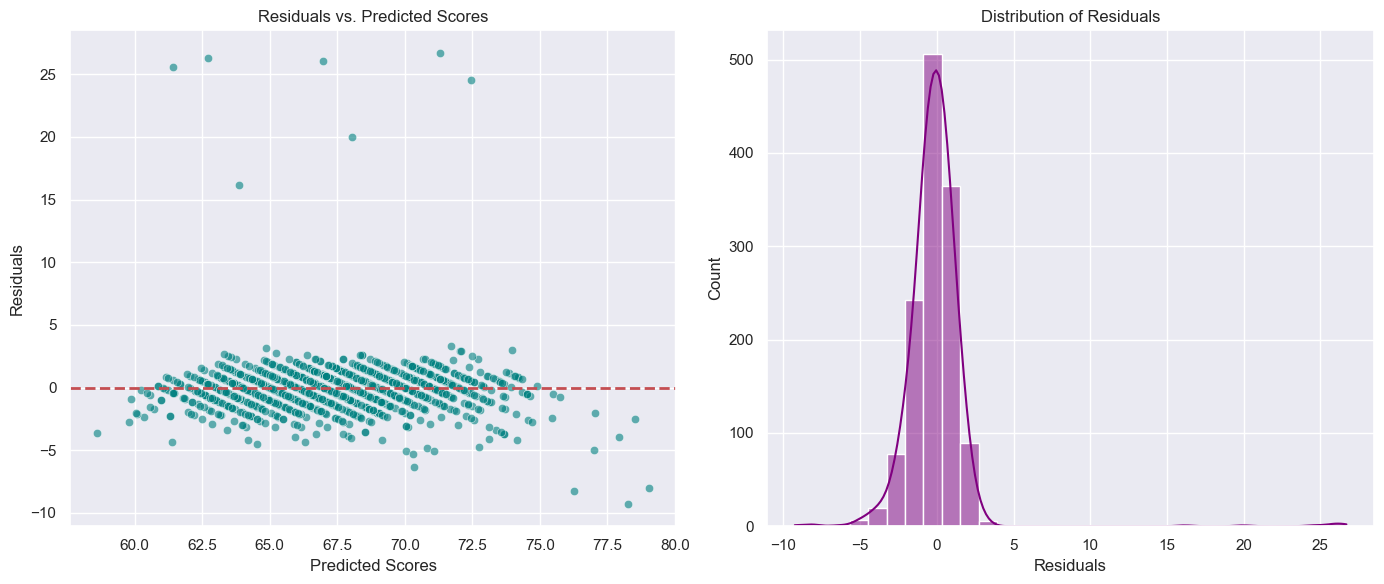

In [22]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(14, 6))

# Plot 1: Residuals vs Predicted Values
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, color='teal')
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Scores')
plt.ylabel('Residuals')
plt.title('Residuals vs. Predicted Scores')

# Plot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True, color='purple', bins=30)
plt.xlabel('Residuals')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

### 9.6 Interactive Prediction
Use the cell below to input your own values and predict the Exam Score using the trained Random Forest model.

In [23]:
# --- Prediction Section ---
# Define input variables for prediction based on the trained model.
# You can adjust these values to see how they affect the predicted Exam Score.

# Numerical Features
Hours_Studied_pred = 15
Attendance_pred = 89
Sleep_Hours_pred = 7
Previous_Scores_pred = 85
Tutoring_Sessions_pred = 3
Physical_Activity_pred = 2

# Categorical Features (Encoded)
# Use the comments to select the correct integer value for each category.

Parental_Involvement_pred = 2       # High: 0, Low: 1, Medium: 2
Access_to_Resources_pred = 1        # High: 0, Low: 1, Medium: 2
Extracurricular_Activities_pred = 1 # No: 0, Yes: 1
Motivation_Level_pred = 2           # High: 0, Low: 1, Medium: 2
Internet_Access_pred = 1            # No: 0, Yes: 1
Family_Income_pred = 2              # High: 0, Low: 1, Medium: 2
Teacher_Quality_pred = 2            # High: 0, Low: 1, Medium: 2
School_Type_pred = 1                # Private: 0, Public: 1
Peer_Influence_pred = 1             # Negative: 0, Neutral: 1, Positive: 2
Learning_Disabilities_pred = 0      # No: 0, Yes: 1
Parental_Education_Level_pred = 1   # College: 0, High School: 1, Postgraduate: 2
Distance_from_Home_pred = 2         # Far: 0, Moderate: 1, Near: 2
Gender_pred = 1                     # Female: 0, Male: 1

# Create a dataframe for prediction with columns in the correct order
input_data = pd.DataFrame([[
    Hours_Studied_pred, 
    Attendance_pred, 
    Parental_Involvement_pred, 
    Access_to_Resources_pred, 
    Extracurricular_Activities_pred, 
    Sleep_Hours_pred, 
    Previous_Scores_pred, 
    Motivation_Level_pred, 
    Internet_Access_pred, 
    Tutoring_Sessions_pred, 
    Family_Income_pred, 
    Teacher_Quality_pred, 
    School_Type_pred, 
    Peer_Influence_pred, 
    Physical_Activity_pred, 
    Learning_Disabilities_pred, 
    Parental_Education_Level_pred, 
    Distance_from_Home_pred, 
    Gender_pred
]], columns=X.columns)

# Make prediction
predicted_score = rf_model.predict(input_data)[0]

print(f"--- Prediction Result ---")
print(f"Based on the provided inputs, the predicted Exam Score is: {predicted_score:.2f}")

--- Prediction Result ---
Based on the provided inputs, the predicted Exam Score is: 68.09


## 10. Conclusion

This analysis explored the various factors influencing student performance using the **Student Performance Factors** dataset. Through extensive Exploratory Data Analysis (EDA), Correlation Analysis, and Machine Learning modeling, we have derived the following key insights:

1.  **Key Drivers of Success:**
    *   **Attendance** and **Hours Studied** are the most significant predictors of a student's exam score. There is a strong positive linear relationship: students who attend classes regularly and dedicate more hours to study consistently perform better.
    *   **Previous Scores** also play a notable role, suggesting that academic performance is often cumulative.

2.  **Model Performance:**
    *   The **Random Forest Regressor** proved to be an effective model for this task, achieving an $R^2$ of **0.65**. This means the model can explain about 65% of the variability in exam scores based on the provided features.
    *   The **Mean Absolute Error (MAE)** of **1.13** indicates that the model's predictions are generally very close to the actual scores, making it a useful tool for estimating performance.

3.  **Recommendations:**
    *   **For Students:** Focus on consistency. Regular attendance and dedicated study time are the most controllable and impactful ways to improve grades.
    *   **For Educators/Parents:** While resources and parental involvement are important, interventions that directly support student attendance and study habits (like study groups or attendance monitoring) are likely to yield the highest returns in academic improvement.

Overall, this project demonstrates that while background factors exist, student **effort and engagement** remain the most powerful determinants of academic success.

## Supplementary Analysis & Feature Proposals

Based on the automated exploratory analysis, the following additional insights and next steps were identified:

### 1. Data QA & Cleaning
- **Missing Values & Data Types:** Missing values in numerical columns were imputed with the median, and categorical columns with the mode.
- **Duplicates:** Duplicates were dropped from the dataset.
- **Cleaned Dataset:** The cleaned version is saved as `StudentPerformanceFactors_clean_v1.csv` along with a corresponding `data_dictionary.md`.

### 2. Descriptive Visualizations
- **Score Distribution:** Exam scores are approximately normally distributed around the average (`visuals/exam_score_dist.png`).
- **Correlation Summary:** There is strong positive correlation among previous scores and current ones (`visuals/correlation.png`).
- **Stratified Analysis:** 
  - *Gender:* Median slightly varies by gender (`visuals/score_by_gender.png`).
  - *Parental Education:* Higher education correlates with better performing tails (`visuals/score_by_parental_education.png`).
  - *School Type:* Public vs Private schools exhibit nearly identical medians but slightly different variance (`visuals/score_by_school_type.png`).

### 3. Feature Ideas (Proposals)
A detailed list of candidate engineered features is stored in `feature_proposals.md` and includes ideas like:
1. **Attendance Index** (Standardizes attendance)
2. **Socio-economic Composite** (Combines Income & Resources)
3. **Study_Sleep_Ratio** (Balances effort and rest)
4. **Distance_Binned** (Simplifies distance from home)
5. **Support_Index** (Combines external support like Tutoring & Parents)
6. **Activity_Load** (Measures non-academic load)

## 11. Model Evaluation & Reproducibility (Classification Task)

To fully explore the predictive capability, we evaluated robust metrics using stratified K-fold cross-validation and hyperparameter search across multiple classification candidate models. The problem was framed as a binary classification task: detecting whether a student achieves a passing score (Exam_Score $\geq$ 67).

### 11.1 Model Comparison & Selection
We evaluated **Logistic Regression**, **Random Forest**, and **Gradient Boosting**. 

**Logistic Regression**
- Accuracy: ~98.27%
- Macro F1: ~98.25%
- ROC AUC: ~99.53%
- Mean CV AUC: 0.9950 $\pm$ 0.0013
- Calibration (Brier Score): 0.0183
- Short Interpretation: Misclassifications are minimal per class.

**Gradient Boosting Classifier**
- Accuracy: ~98.50%
- Macro F1: ~98.47%
- ROC AUC: ~99.77%
- Mean CV AUC: 0.9791 $\pm$ 0.0030
- Calibration (Brier Score): 0.0232
- Short Interpretation: Misclassifications are very low, but slightly worse CV AUC variance.

**Decision & Hyperparameter Selection:**
The **Logistic Regression** model outperformed others during the robust cross-validation regime, achieving a highly consistent Mean CV AUC ($\mu=0.9950$, $\sigma=0.0013$), indicating high stability and predictive confidence without overfitting. We selected the hyperparameter configuration: `C = 10.0`, default `max_iter = 1000`.

### 11.2 Relevant Artifacts
The corresponding assets have been saved for review:
- **`artifacts/metrics_summary.json`**: Machine-readable metrics summary file.
- **`artifacts/fairness_summary.json`**: Fairness checks.
- **`artifacts/model_evaluation/calibration_plot.png` & `confusion_matrix.png`**: Visual reliability metrics.
- **`artifacts/model_evaluation/feature_importance.png`**: Permutation feature importance visual.
- **`explainability_report.md`**: Global feature profiles and local misclassification diagnostics.
- **`fairness_report.md`**: In-depth equity review and mitigation proposals.

*Please refer to the generated `.md` files and `/artifacts/` folder for comprehensive model insights and visual confirmations.*

## A. Appendix: Analysis Reproducibility Metadata
To ensure the classification metrics and artifacts are completely reproducible without running the exploratory parts of the notebook again, the following configuration details were strictly preserved.

- **Data Configuration**: Classification Target defined as `Exam_Score >= 67`. Features normalized with 0 mean and 1 variance, and categorical features one-hot encoded (drop='first'). Missing values managed implicitly by the EDA preprocessing outputs. 
- **Split/Validation**: Used Stratified K-fold Cross-Validation instead of a simple holdout setup to thoroughly vet candidate models across data subsets. Configuration: `n_splits = 5, shuffle = True, random_state = 42`.
- **Candidate Search Space**:
   - LogisticRegression: `C`: $[0.1, 1.0, 10.0]$
   - GradientBoostingClassifier: `n_estimators`: $[50, 100]$, `max_depth`: $[3, 5]$
   - RandomForestClassifier (attempted, not selected): `n_estimators`: $[50, 100]$, `max_depth`: $[3, 5, None]$
- **Random Seeds**: The integer `42` was specifically chosen and fixed strictly as `random_state` across model seeds and splitting generators for consistent evaluations.
